In [4]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
import os
from os import path
from PIL import Image

#Uncomment if running in Jupyter Notebook
%matplotlib inline 


# DIRECTORY SETUP
os.makedirs('models', exist_ok=True)
os.makedirs('assets', exist_ok=True)

# NLTK SETUP
print("[*] Downloading NLTK resources")
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[*] Downloading NLTK resources


In [5]:
# DATA LOADING
try:
    df = pd.read_csv('assets/spam_NLP.csv', sep=',', quotechar='"', names=['id', 'label', 'text'], skiprows=1)

    print(f"[+] Successfully loaded {len(df)} rows.")

    # Data validation and mapping
    df = df[df['label'].astype(str).isin(['0', '1'])]
    df['label'] = df['label'].astype(int).map({1: 'spam', 0: 'ham'})
    df.dropna(inplace=True)
    print(df)

except Exception as e:
    print(f"[-] FATAL ERROR loading dataset: {e}")

[+] Successfully loaded 5796 rows.
        id label                                               text
0        0  spam  Dear Homeowner,\n\n \n\nInterest Rates are at ...
1        1  spam  ATTENTION: This is a MUST for ALL Computer Use...
2        2  spam  This is a multi-part message in MIME format.\n...
3        3  spam  IMPORTANT INFORMATION:\n\n\n\nThe new domain n...
4        4  spam  This is the bottom line.  If you can GIVE AWAY...
...    ...   ...                                                ...
5791  5791   ham  I'm one of the 30,000 but it's not working ver...
5792  5792   ham  Damien Morton quoted:\n\n>W3C approves HTML 4 ...
5793  5793   ham  On Mon, 2002-07-22 at 06:50, che wrote:\n\n\n\...
5794  5794   ham  Once upon a time, Manfred wrote :\n\n\n\n> I w...
5795  5795   ham  If you run Pick, and then use the "New FTOC" b...

[5796 rows x 3 columns]


In [6]:
# DATA CLEANING
print("--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATE REMOVAL ---")
initial_count = len(df)
df.drop_duplicates(inplace=True)
final_count = len(df)
print(f"[*] Removed {initial_count - final_count} duplicates. {final_count} unique messages remain.")

# FEATURE ENGINEERING: MESSAGE LENGTH
df['length'] = df['text'].apply(len) # Character count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split())) # Word count

print("\n--- LENGTH STATISTICS HAM/SPAM ---")
print("\n-= CHARACTERS =-")
print(df.groupby('label')['length'].describe())

print("\n-= WORDS =-")
print(df.groupby('label')['word_count'].describe())

# EXTREME VALUES ANALYSIS
print("\n--- EXTREME VALUES ---")
# MIN
min_len = df['length'].min()
shortest_msg = df[df['length'] == min_len]['text'].iloc[0]
print(f"[*] Shortest message: {min_len} chars, {len(shortest_msg.split())} words.")
print(f"    Content: '{shortest_msg}'")

# MAX
max_len = df['length'].max()
longest_msg = df[df['length'] == max_len]['text'].iloc[0]
print(f"\n[*] Longest message: {max_len} chars, {len(longest_msg.split())} words.")
print(f"    Content: '{longest_msg[:200]}...'")

# AVG
avg_len = df['length'].mean()
avg_words = df['word_count'].mean()
print(f"\n[*] Average: {avg_len:.2f} chars | {avg_words:.2f} words per message.")

# CLASS DISTRIBUTION
total = len(df)
spam_perc = (len(df[df['label']=='spam'])/total)*100
ham_perc = (len(df[df['label']=='ham'])/total)*100

print("\n--- DISTRIBUTION ---")
print(f"HAM: {ham_perc:.2f}% | SPAM: {spam_perc:.2f}%")

--- MISSING VALUES ---
id       0
label    0
text     0
dtype: int64

--- DUPLICATE REMOVAL ---
[*] Removed 0 duplicates. 5796 unique messages remain.

--- LENGTH STATISTICS HAM/SPAM ---

-= CHARACTERS =-
        count         mean          std   min      25%     50%      75%  \
label                                                                     
ham    3900.0  1615.114359   3890.48116  54.0   545.75   987.0  1640.00   
spam   1896.0  5178.556435  10372.98178  36.0  1113.75  2543.5  5730.25   

            max  
label            
ham    110372.0  
spam   234358.0  

-= WORDS =-
        count        mean         std  min    25%    50%    75%      max
label                                                                   
ham    3900.0  232.994872  570.853287  1.0   73.0  140.0  242.0  14954.0
spam   1896.0  449.258439  720.896880  2.0  118.0  252.0  498.0  11620.0

--- EXTREME VALUES ---
[*] Shortest message: 36 chars, 2 words.
    Content: '.



ukqdrblkougooeoffnxsmbowei




'


C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you w

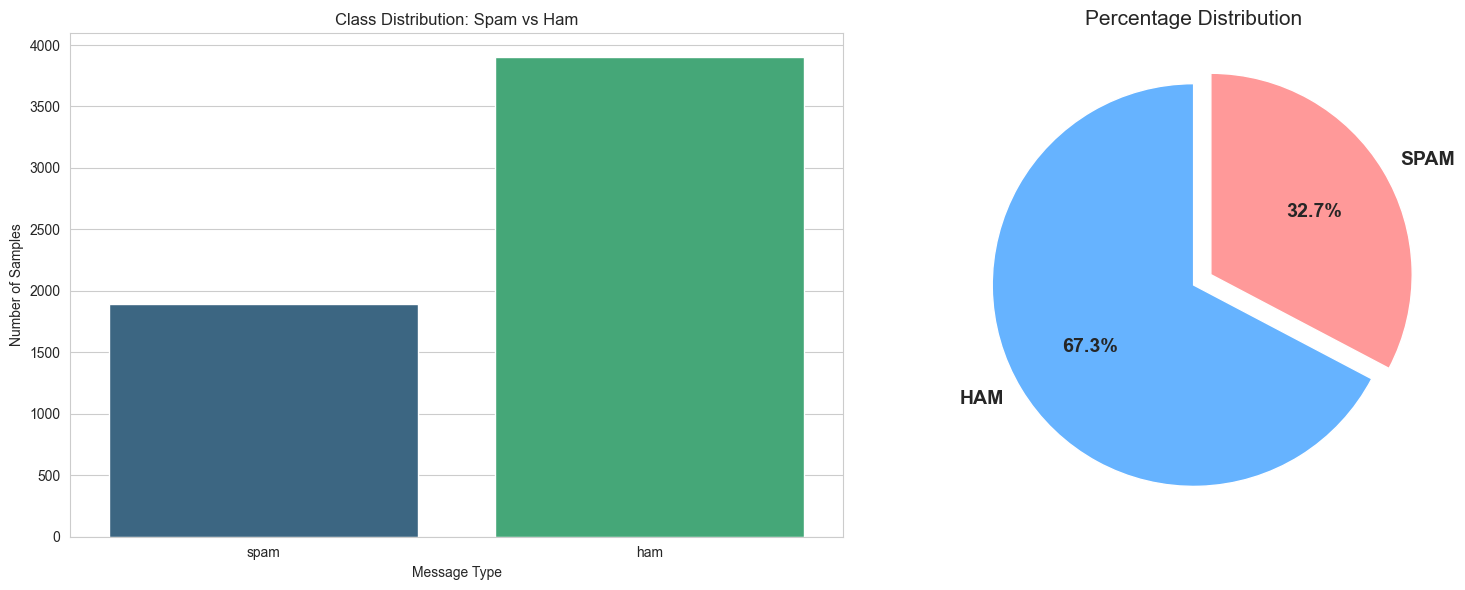

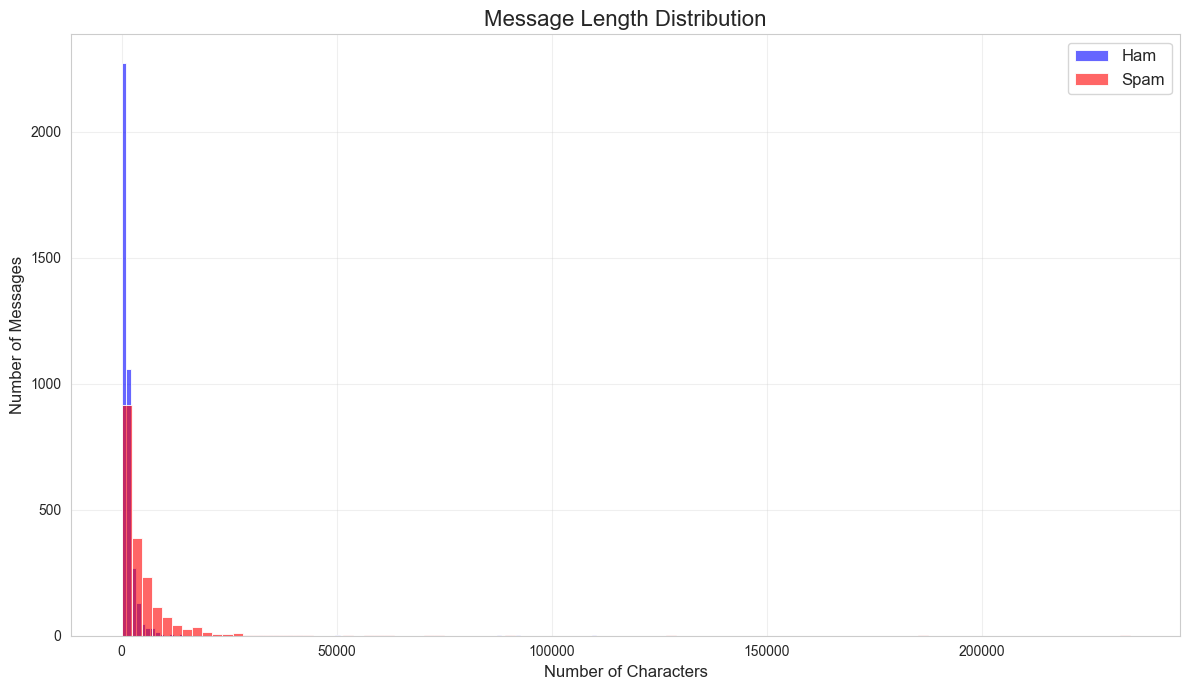

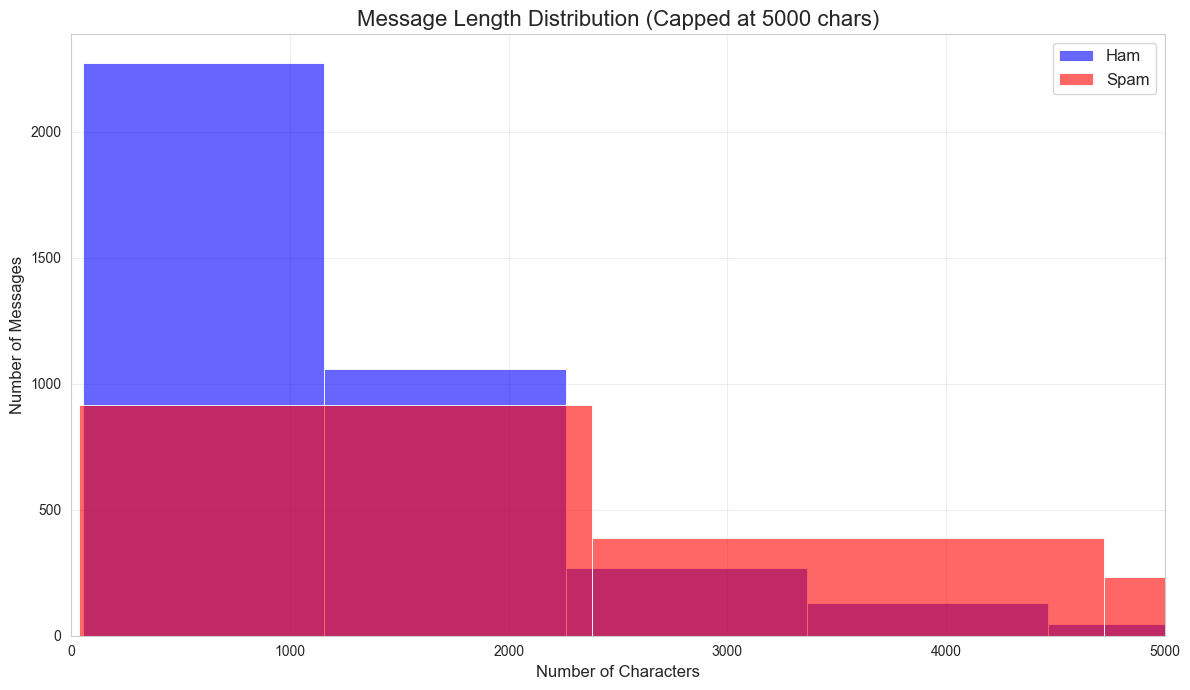

In [7]:
# EDA VISUALIZATIONS
sns.set_style("whitegrid")

# PLOT 1: Class Distribution
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.countplot(x='label', data=df, hue='label', palette='viridis', ax=axes[0])

if axes[0].get_legend():
    axes[0].get_legend().remove()

axes[0].set_title('Class Distribution: Spam vs Ham')
axes[0].set_xlabel('Message Type')
axes[0].set_ylabel('Number of Samples')

counts = df['label'].value_counts()
axes[1].pie(counts, labels=['HAM', 'SPAM'], autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.1),
            textprops={'fontsize': 14, 'weight': 'bold'})
axes[1].set_title('Percentage Distribution', fontsize=15)

plt.tight_layout()
plt.savefig('assets/class_distribution.png')
plt.show()

# PLOT 2: Message Length Distribution
plt.figure(figsize=(12, 7))

sns.histplot(df[df['label'] == 'ham']['length'], bins=100, color='blue', alpha=0.6, label='Ham')
sns.histplot(df[df['label'] == 'spam']['length'], bins=100, color='red', alpha=0.6, label='Spam')

plt.title('Message Length Distribution', fontsize=16)
plt.xlabel('Number of Characters', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/message_length_distribution.png')
plt.show()

# PLOT 3: Message Length Distribution (capped @ 5k chars)
plt.figure(figsize=(12, 7))

sns.histplot(df[df['label'] == 'ham']['length'], bins=100, color='blue', alpha=0.6, label='Ham')
sns.histplot(df[df['label'] == 'spam']['length'], bins=100, color='red', alpha=0.6, label='Spam')

plt.xlim(0, 5000)
plt.title('Message Length Distribution (Capped at 5000 chars)', fontsize=16)
plt.xlabel('Number of Characters', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('assets/message_length_distribution_capped_5k_chars.png')
plt.show()

In [9]:
# TEXT PREPROCESSING PIPELINE
def preprocessing_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(cleaned_words)

print("\n[*] Text Preprocessing - INITIALIZING")
df['clean_text'] = df['text'].apply(preprocessing_pipeline)
print("[*] Text Preprocessing - COMPLETED\n")

print("BEFORE:\n", df['text'].iloc[0])
print("AFTER:\n", df['clean_text'].iloc[0])


[*] Text Preprocessing - INITIALIZING
[*] Text Preprocessing - COMPLETED

BEFORE:
 Dear Homeowner,

 

Interest Rates are at their lowest point in 40 years!



We help you find the best rate for your situation by

matching your needs with hundreds of lenders!



Home Improvement, Refinance, Second Mortgage,

Home Equity Loans, and More! Even with less than

perfect credit!



This service is 100% FREE to home owners and new

home buyers without any obligation. 



Just fill out a quick, simple form and jump-start

your future plans today!





Visit http://61.145.116.186/user0201/index.asp?Afft=QM10













To unsubscribe, please visit:



http://61.145.116.186/light/watch.asp





AFTER:
 dear homeowner interest rate lowest point year help find best rate situation matching need hundred lender home improvement refinance second mortgage home equity loan even less perfect credit service free home owner new home buyer without obligation fill quick simple form jumpstart future plan t

In [10]:
# VECTORIZATION
print("\n--- VECTORIZATION ---")
# TF-IDF (Term Frequency - Inverse Document Frequency)
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()
print(f"[*] TF-IDF Vectorizer fitted. Matrix shape: {X_tfidf.shape}")

# LABELS & TRAIN/TEST SPLIT
y = df['label'].map({'spam': 1, 'ham': 0})
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=2137, stratify=y)
print(f"[*] Data split completed. Train: {X_train.shape}, Test: {X_test.shape}")


--- VECTORIZATION ---
[*] TF-IDF Vectorizer fitted. Matrix shape: (5796, 5000)
[*] Data split completed. Train: (4636, 5000), Test: (1160, 5000)


In [11]:
# MODEL TRAINING & EVALUATION
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM (Linear)": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=2137),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2137)
}

results = []

print("\n--- MODEL TRAINING ---")

for name, model in models.items():
    print(f"\n[*] Training: {name}...")
    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end_time = time.time()
    duration = end_time - start_time

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"    Finished in {duration:.2f}s")
    print(f"    Accuracy: {acc: .4f}  | F1-Score: {f1: .4f}")
    print(f"    Precision: {prec: .4f} | Recall: {rec: .4f}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Time (s)": duration
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)

print("\n--- LEADERBOARD ---")
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nBEST MODEL (by F1-Score): {best_model_name}")

results_df.to_csv('assets/model_results.csv', index=False)
print("[*] Results saved to 'assets/model_results.csv'")


--- MODEL TRAINING ---

[*] Training: Naive Bayes...
    Finished in 0.05s
    Accuracy:  0.9793  | F1-Score:  0.9675
    Precision:  0.9944 | Recall:  0.9420

[*] Training: Logistic Regression...
    Finished in 0.37s
    Accuracy:  0.9776  | F1-Score:  0.9646
    Precision:  0.9972 | Recall:  0.9340

[*] Training: SVM (Linear)...
    Finished in 10.62s
    Accuracy:  0.9897  | F1-Score:  0.9840
    Precision:  0.9946 | Recall:  0.9736

[*] Training: Random Forest...
    Finished in 9.30s
    Accuracy:  0.9776  | F1-Score:  0.9657
    Precision:  0.9657 | Recall:  0.9657

[*] Training: Gradient Boosting...
    Finished in 91.76s
    Accuracy:  0.9578  | F1-Score:  0.9322
    Precision:  0.9797 | Recall:  0.8892

--- LEADERBOARD ---
                 Model  Accuracy  Precision    Recall  F1-Score   Time (s)
2         SVM (Linear)  0.989655   0.994609  0.973615  0.984000  10.618536
0          Naive Bayes  0.979310   0.994429  0.941953  0.967480   0.046006
3        Random Forest  0.97758

In [12]:
# HYPERPARAMETER TUNING (GRID SEARCH)
print(f"--- Hyperparameter Tuning for: {best_model_name} ---")

param_grids = {
    "Naive Bayes": {'alpha': [0.1, 0.5, 1.0]},
    "Logistic Regression": {'C': [0.1, 1, 10, 100]},
    "SVM (Linear)": {'C': [0.1, 1, 10]},
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20]
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

if best_model_name == "SVM (Linear)":
    model_to_tune = SVC(kernel='linear', probability=True, random_state=2137)
    
elif best_model_name == "Logistic Regression":
    model_to_tune = LogisticRegression(random_state=2137, max_iter=1000)
    
elif best_model_name == "Random Forest":
    model_to_tune = RandomForestClassifier(random_state=2137)
    
elif best_model_name == "Gradient Boosting":
    model_to_tune = GradientBoostingClassifier(random_state=2137)
    
elif best_model_name == "Naive Bayes":
    model_to_tune = MultinomialNB()
    
else:
    print("[-] Error: Model not found")

grid_params = param_grids[best_model_name]

grid_search = GridSearchCV(model_to_tune, grid_params, cv=3, scoring='f1', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\n[*] Tuning - COMPLETED")
print(f"[*] Best parameters: {grid_search.best_params_}")
print(f"[*] Best F1-Score during cross-validation: {grid_search.best_score_:.4f}")

best_model_grdSrch = grid_search.best_estimator_

print("\n--- Final Test on Tuned Model ---")
y_pred_tuned = best_model_grdSrch.predict(X_test)
print(classification_report(y_test, y_pred_tuned))

--- Hyperparameter Tuning for: SVM (Linear) ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits

[*] Tuning - COMPLETED
[*] Best parameters: {'C': 10}
[*] Best F1-Score during cross-validation: 0.9834

--- Final Test on Tuned Model ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       781
           1       0.99      0.98      0.99       379

    accuracy                           0.99      1160
   macro avg       0.99      0.99      0.99      1160
weighted avg       0.99      0.99      0.99      1160



In [13]:
# SAVING ARTIFACTS
print("--- EXPORTING ARTIFACTS ---")

if 'tfidf' in locals() and 'best_model_grdSrch' in locals():
    try:
        joblib.dump(tfidf, 'models/vectorizer.pkl')
        vec_size = os.path.getsize('models/vectorizer.pkl') / 1024
        print(f"[+] Vectorizer saved to 'models/vectorizer.pkl' ({vec_size:.2f} KB)")

        joblib.dump(best_model_grdSrch, 'models/model.pkl')
        model_size = os.path.getsize('models/model.pkl') / 1024
        print(f"[+] Model saved to 'models/model.pkl' ({model_size:.2f} KB)")
        
        print("[*] Export complete. System ready for deployment.")
    except Exception as e:
        print(f"[-] ERROR saving artifacts: {e}")
else:
    print("[-] Error: 'tfidf' or 'best_model_grdSrch not found'")

--- EXPORTING ARTIFACTS ---
[+] Vectorizer saved to 'models/vectorizer.pkl' (183.21 KB)
[+] Model saved to 'models/model.pkl' (33260.46 KB)
[*] Export complete. System ready for deployment.


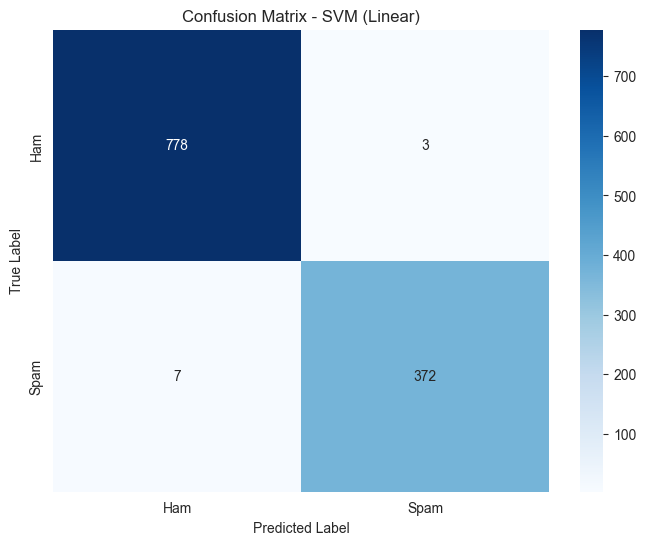

In [14]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('assets/confusion_matrix.png')
plt.show()

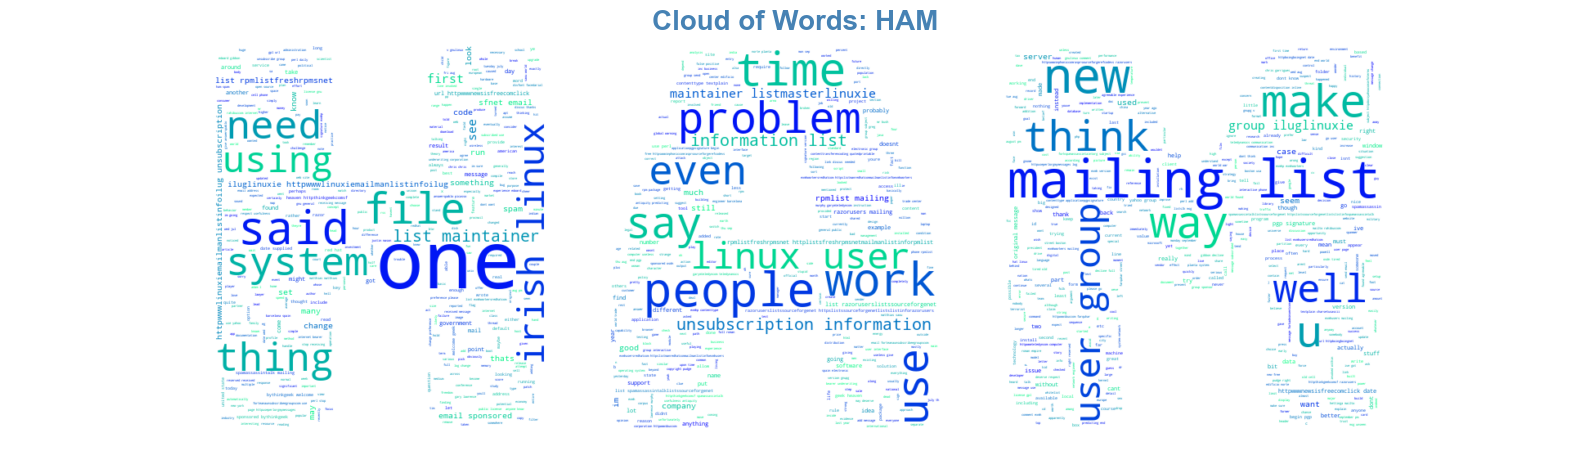

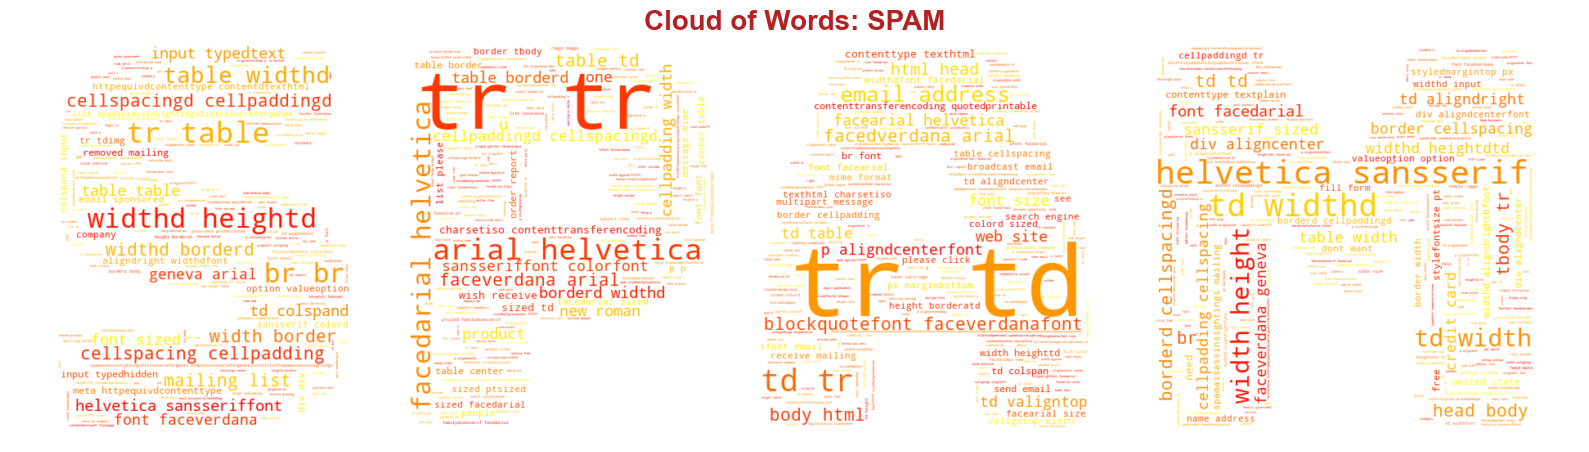

In [15]:
# CLOUD OF WORDS (NLP ANALYSIS)
d = path.dirname(__file__) if "__file__" in locals() else os.getcwd()

try:
    mask_spam = np.array(Image.open(path.join(d, "assets/SPAM.png")))
    try:
        mask_ham = np.array(Image.open(path.join(d, "assets/HAM.png")))
    except FileNotFoundError:
        print("[-] HAM.png mask not found, using SPAM mask for both.")
        mask_ham = mask_spam

except FileNotFoundError:
    print("[-] Mask images not found. Proceeding without masks.")
    mask_spam, mask_ham = None, None

MAX_WORDS = 3000

# CoW HAM
plt.figure(figsize=(16, 10))

ham_text = " ".join(df[df['label'] == 'ham']['clean_text'])

wc_ham = WordCloud(
    relative_scaling=0.4,
    background_color='white',
    colormap='winter',
    mask=mask_ham,
    contour_width=0,
    contour_color='steelblue',
    max_words=MAX_WORDS,
    random_state=42
).generate(ham_text)

plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Cloud of Words: HAM', fontsize=20, weight='bold', color='steelblue')

plt.tight_layout()
plt.savefig('assets/cloudOfWords_HAM.png')
plt.show()

# CoW SPAM
plt.figure(figsize=(16, 10))

spam_text = " ".join(df[df['label'] == 'spam']['clean_text'])

wc_spam = WordCloud(
    relative_scaling=0.4,
    background_color='white',
    colormap='autumn',
    mask=mask_spam,
    contour_width=0,
    contour_color='firebrick',
    max_words=MAX_WORDS,
    random_state=42
).generate(spam_text)

plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Cloud of Words: SPAM', fontsize=20, weight='bold', color='firebrick')

plt.tight_layout()
plt.savefig('assets/cloudOfWords_SPAM.png')
plt.show()

--- FEATURE IMPORTANCE (MODEL INTERPRETABILITY) ---
Model SVC uses 'coef_'

[*] TOP 20 SPAM INDICATORS:
                                                  Token    Weight
4890                                                 wi  2.307807
791                                               click  2.168679
3339                                             please  1.982310
390                                                  bc  1.797093
3711                                             remove  1.619822
1876                                               free  1.506881
1441                                              email  1.506576
2918                                              money  1.397931
3948                                               send  1.367991
1091                                             credit  1.329667
1641                                          facearial  1.321885
3158                                              order  1.288221
3480                                  

C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you w

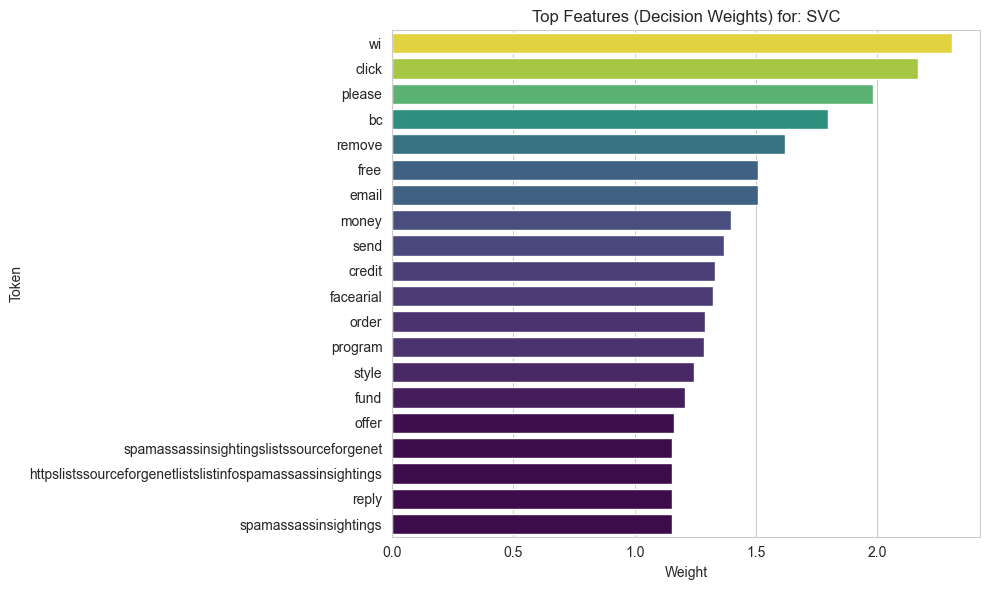

In [18]:
# FEATURE IMPORTANCE (MODEL INTERPRETABILITY)
print("--- FEATURE IMPORTANCE (MODEL INTERPRETABILITY) ---")
trained_model = grid_search.best_estimator_
feature_names = tfidf.get_feature_names_out()
importance = None

# RANDOM FOREST, GRADIENT BOOSTING
if hasattr(trained_model, 'feature_importances_'):
    print(f"Model {type(trained_model).__name__} uses 'feature_importances_'")
    importance = trained_model.feature_importances_
    
# SVM, LOGISTIC REGRESSION)
elif hasattr(trained_model, 'coef_'):
    print(f"Model {type(trained_model).__name__} uses 'coef_'")
    importance = trained_model.coef_[0]
    
# NAIVE BAYES
elif hasattr(trained_model, 'feature_log_prob_'):
    print(f"Model {type(trained_model).__name__} uses 'feature_log_prob_'")
    spam_prob = trained_model.feature_log_prob_[1]
    ham_prob = trained_model.feature_log_prob_[0]
    importance = spam_prob - ham_prob
    
else:
    print(f"Error: {e}")

if importance is not None:
    feat_importances = pd.DataFrame({'Token': feature_names, 'Weight': importance})
    feat_importances = feat_importances.sort_values(by='Weight', ascending=False)

    print("\n[*] TOP 20 SPAM INDICATORS:")
    print(feat_importances.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Weight', y='Token', data=feat_importances.head(20), hue='Weight', palette='viridis', legend=False)
    plt.title(f'Top Features (Decision Weights) for: {type(trained_model).__name__}')
    plt.tight_layout()
    plt.savefig('assets/top_words_4_spam.png')
    plt.show()

In [19]:
# --- ERROR ANALYSIS (FALSE POSITIVES & NEGATIVES) ---
print("\n--- ERROR ANALYSIS ---")
analysis_df = df.loc[y_test.index].copy()
analysis_df['True_Label'] = y_test
analysis_df['Prediction'] = y_pred_tuned

fp_cases = analysis_df[(analysis_df['True_Label'] == 0) & (analysis_df['Prediction'] == 1)]
fn_cases = analysis_df[(analysis_df['True_Label'] == 1) & (analysis_df['Prediction'] == 0)]

print(f"[*] Found {len(fp_cases)} False Positives and {len(fn_cases)} False Negatives.")

print("\n" + "="*50 + "\nFALSE POSITIVES (Ham predicted as Spam)\n" + "="*50)
for idx, row in fp_cases.head(3).iterrows():
    print(f"\n[Original ID: {idx}]")
    print(f"Content (first 400 chars):\n{str(row['text'])[:400]}...")
    print("-" * 30)

print("\n" + "="*50 + "\nFALSE NEGATIVES (Spam predicted as Ham)\n" + "="*50)
for idx, row in fn_cases.head(3).iterrows():
    print(f"\n[Original ID: {idx}]")
    print(f"Content (first 400 chars):\n{str(row['text'])[:400]}...")
    print("-" * 30)


--- ERROR ANALYSIS ---
[*] Found 3 False Positives and 7 False Negatives.

FALSE POSITIVES (Ham predicted as Spam)

[Original ID: 2200]
Content (first 400 chars):




> Another thing to note about Australia is that, while the highest income

> tax bracket (47%) isn't *that* high, it kicks in at around USD33,000.



and it looks like PPP for USD 33k is only

about USD 50k*, at least in Big Macs:



<http://www.economist.com/images/20020427/CFN751.gif>

Australia	 A$3.00 USD 1.62	-35%

US		  $2.49 USD 2.49

Switzerland	SFr6.30 USD 3.81	+53%



Interestingly e...
------------------------------

[Original ID: 2131]
Content (first 400 chars):
This is an automated response to a message you have sent to hauns_froehlingsdorf@infinetivity.com.



I will be out of the office until Monday, August 26 2002.



I will reply to your email when I return.



Hauns



___________________________________



Hauns Froehlingsdorf

Network/Systems Manager

infinetivity, inc.

952-225.4200

http://www.infin

C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\Bone0\Desktop\PORTFOLIO NA GITA\mlops-spam-classifier\venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you w

[*] Plot saved to 'assets/f1_score_comparison.png'


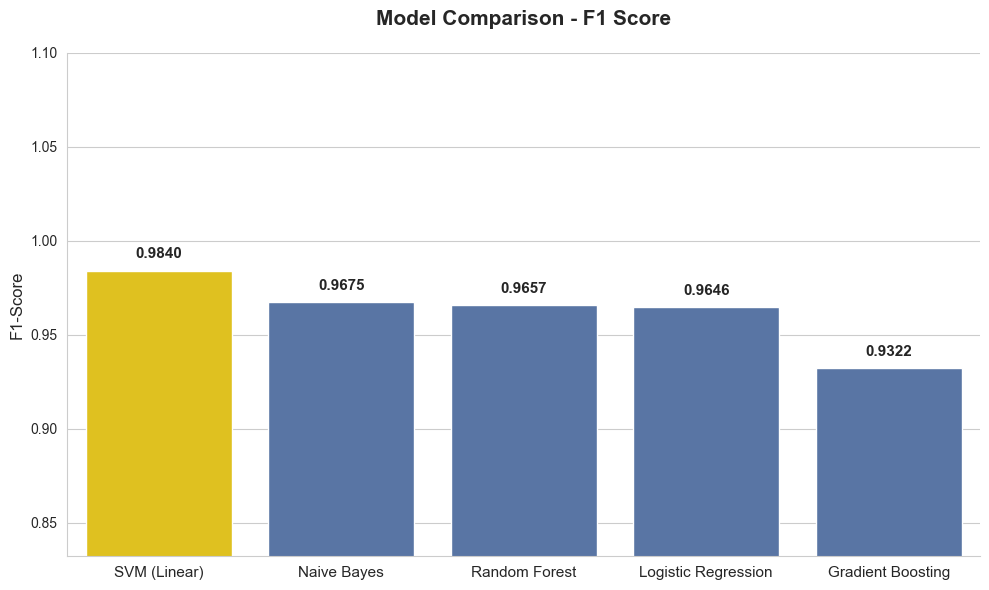

In [50]:
# BAR PLOT: MODEL COMPARISON
df_plot = results_df.copy()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = ['#FFD700' if x == df_plot['F1-Score'].max() else '#4c72b0' for x in df_plot['F1-Score']]

ax = sns.barplot(x='Model', y='F1-Score', data=df_plot, palette=colors, hue = 'Model')

for i, v in enumerate(df_plot['F1-Score']):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

ylimMin = df_plot['F1-Score'].min() - 0.1
ylimMax = round(df_plot['F1-Score'].max()) + 0.1

plt.ylim(ylimMin, ylimMax) 
plt.title('Model Comparison - F1 Score', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.xticks(fontsize=11)

sns.despine()

plt.tight_layout()
plt.savefig('assets/f1_score_comparison.png', dpi=300)
print("[*] Plot saved to 'assets/f1_score_comparison.png'")
plt.show()

--- GENERATING HYPERPARAMETER TUNING PLOT ---
Testing C = 0.1
Testing C = 1
Testing C = 10
PLOTTING DATA...


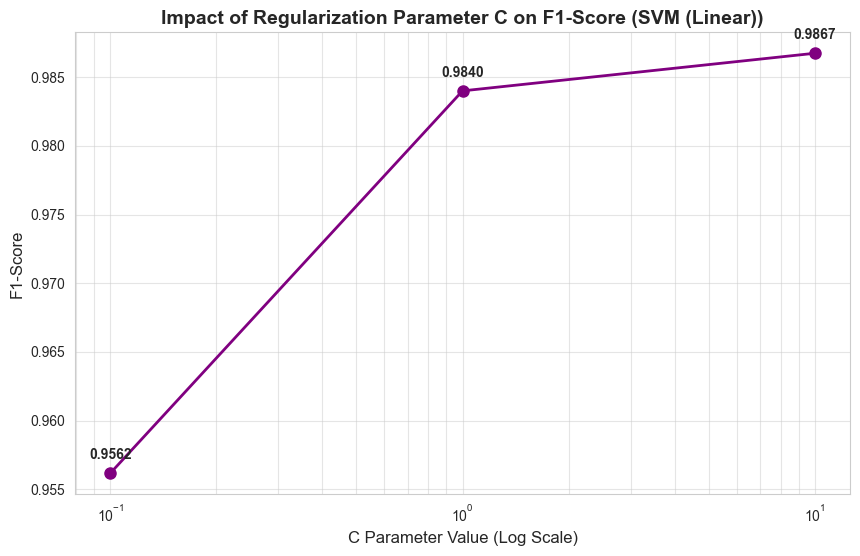

In [51]:
C_values = [0.1, 1, 10]
f1_results = []

print("--- GENERATING HYPERPARAMETER TUNING PLOT ---")

for C_val in C_values:
    print(f"Testing C = {C_val}")
    model_temp = SVC(kernel='linear', C=C_val)
    model_temp.fit(X_train, y_train)
    

    y_pred_temp = model_temp.predict(X_test)
    score = f1_score(y_test, y_pred_temp)
    f1_results.append(score)

print("PLOTTING DATA...")

plt.figure(figsize=(10, 6))
plt.plot(C_values, f1_results, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.xscale('log')
plt.title(f'Impact of Regularization Parameter C on F1-Score ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('C Parameter Value (Log Scale)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)

for i, txt in enumerate(f1_results):
    plt.annotate(f"{txt:.4f}", (C_values[i], f1_results[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.savefig('assets/hyperparameter_tuning.png')
plt.show()